# Bayesian registration versus the nlreg1d timing analysis

### Background

The nlreg1d paper tests for **timing effects** between two groups by (1) registering all
observations with SRSF alignment, (2) computing each observation's displacement field
d_i(t) (deviation from linear time), and (3) running a two-sample test on the d_i(t) with
nonparametric (permutation, max-t) inference; amplitude effects are tested the same way on the
registered observations. Registration is treated as a deterministic preprocessing step: each
warp is a point estimate, and the uncertainty of the registration itself does not enter the
inference.

**Bayesian registration** (Cheng, Dryden & Huang 2016; Lu, Herbei & Kurtek 2017) instead treats
each warp as an unknown with a posterior distribution: with a Gaussian error model in SRSF space
and a smoothness prior on the warp, MCMC yields posterior samples of γ_i, hence posterior means
and credible bands for the displacement fields. `reg1d.bayes` implements a simplified version
(finite cosine basis in the tangent space of the identity warp, pCN Metropolis sampling, Gibbs
update of the noise variance; see `ALGORITHMS.md`).

This notebook reproduces the nlreg1d analysis of the two simulated datasets — **A** (pure
amplitude effect) and **B** (pure timing effect) — with `registration1d`, then repeats it with Bayesian
registration and compares the conclusions.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))   # so that this notebook finds registration1d without installation
import numpy as np
from matplotlib import pyplot as plt
import registration1d as reg1d
import util                                      # notebooks/util.py: example datasets and permutation tests
print('registration1d version:', reg1d.__version__)

registration1d version: 0.0.2


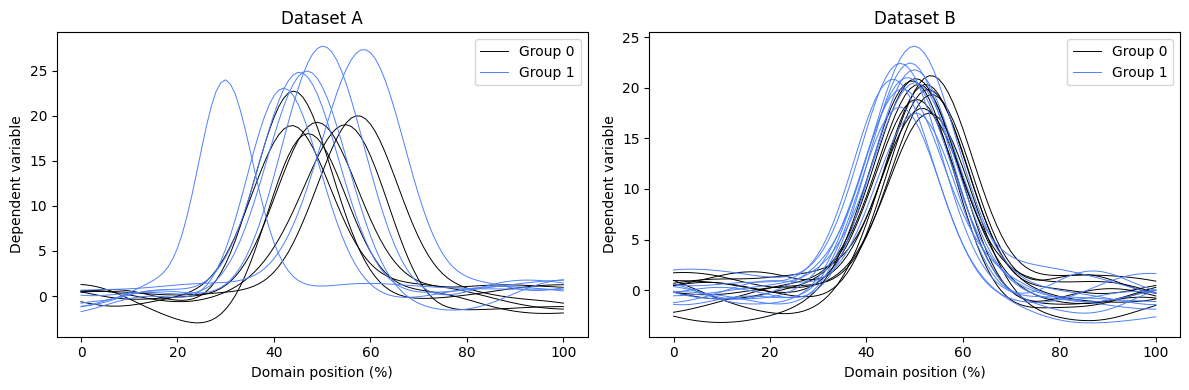

In [2]:
from registration1d import bayes
np.random.seed(0)
t      = np.linspace(0, 1, 101)
colors = ['0.0', (0.3,0.5,0.99)]

def load(name):
    ds = util.SimulatedA() if name == 'A' else util.SimulatedB()
    return ds.y, ds.group

def plot_groups(y, group, ax, title, ylabel=''):
    reg1d.plot.plot_curves(y, group=group, ax=ax, colors=colors, x='percent', lw=0.7,
                           labels=['Group 0', 'Group 1'])
    ax.set_title(title); ax.set_xlabel('Domain position (%)'); ax.set_ylabel(ylabel)

def plot_test(res, ax, title):
    x = np.linspace(0, 100, res['t'].size)
    ax.plot(x, res['t'], 'k'); ax.axhline(res['threshold'], color='r', ls='--'); ax.axhline(-res['threshold'], color='r', ls='--')
    for lo,hi in res['clusters']:
        ax.axvspan(x[lo], x[hi], color='r', alpha=0.2)
    ax.axhline(0, color='k', lw=0.5); ax.set_title(f"{title}  (p = {res['p']:.3f})"); ax.set_xlabel('Domain position (%)'); ax.set_ylabel('t')

fig,AX = plt.subplots(1, 2, figsize=(12,4))
for ax,name in zip(AX, 'AB'):
    y,g = load(name); plot_groups(y, g, ax, f'Dataset {name}', 'Dependent variable')
plt.tight_layout(); plt.show()

## 1. The nlreg1d analysis with registration1d (point-estimate registration)

SRSF registration (5 iterations, as in `fig_datasetA.py` / `fig_datasetB.py`), followed by
permutation two-sample tests on the registered data (amplitude) and on the displacement fields
(timing). `reg1d.util.timing_test` wraps both tests; the permutation inference uses the maximum
|t| over the domain (the "tmax" inference of SnPM).

lam =     0 (used 0.0), dataset A: amplitude p = 0.006 [(35, 63)],  timing p = 0.001 [(1, 18)]


lam =     0 (used 0.0), dataset B: amplitude p = 0.479 [],  timing p = 0.005 [(34, 63)]


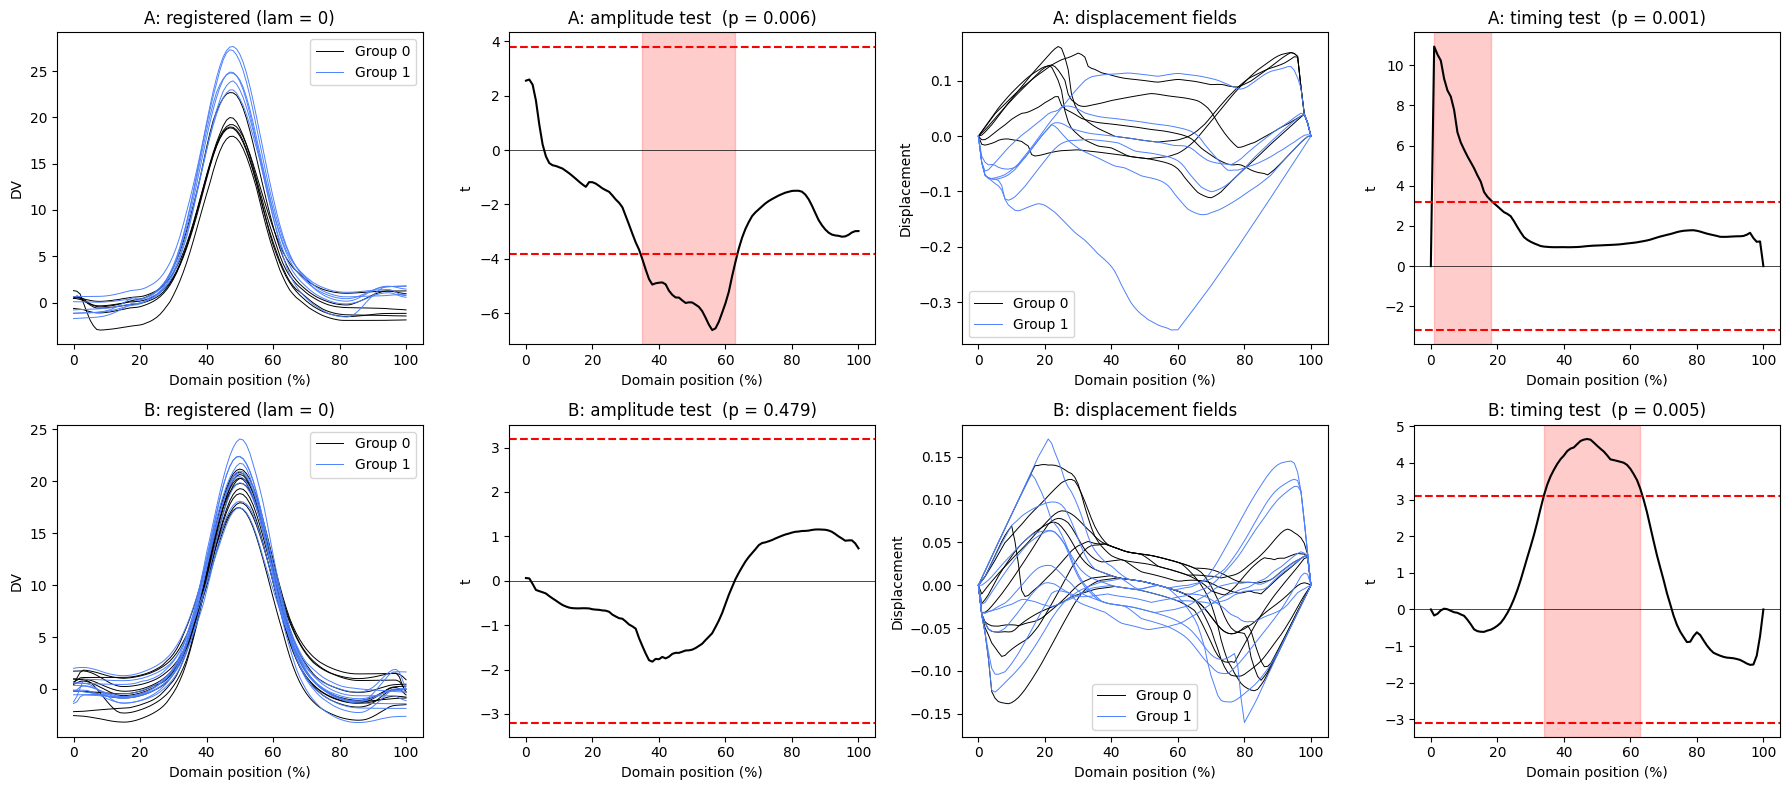

In [3]:
def analyse(lam, show=True):
    out = {}
    if show:
        fig,AX = plt.subplots(2, 4, figsize=(18,8))
    for row,name in enumerate('AB'):
        y,g   = load(name)
        r     = reg1d.register_srsf(y, max_iter=5, lam=lam)
        ta,tt = util.timing_test(r, g, n_perm=1000, random_state=0)
        out[name] = dict(result=r, amp=ta, tim=tt)
        print(f'lam = {lam!s:>5s} (used {r.info["lam"]:.1f}), dataset {name}: amplitude p = {ta["p"]:.3f} {ta["clusters"]},  timing p = {tt["p"]:.3f} {tt["clusters"]}')
        if show:
            plot_groups(r.y, g, AX[row,0], f'{name}: registered (lam = {lam})', 'DV')
            plot_test(ta, AX[row,1], f'{name}: amplitude test')
            plot_groups(r.displacement_fields, g, AX[row,2], f'{name}: displacement fields', 'Displacement')
            plot_test(tt, AX[row,3], f'{name}: timing test')
    if show:
        plt.tight_layout(); plt.show()
    return out

point0 = analyse(lam=0)

Dataset B behaves as in the paper (timing effect, no amplitude effect). Dataset A shows the
expected amplitude effect, **but also a spurious timing effect near the start of the domain**.
The displacement fields show why: away from the bump the simulated curves are flat and noisy, and
the SRSF (the square root of the derivative) amplifies that noise, so the dynamic programme finds
large, noise-driven warps in the flat regions where the objective is nearly indifferent. The
same happens with `fdasrsf` (whose warps differ from `registration1d`'s in exactly these regions and
which, on the same data, gives a timing-test p-value of about 0.08 with the permutation test
used here), i.e. the outcome of the timing test in flat regions is decided by algorithmic details
rather than by the data.

The remedy in the SRSF framework is the elasticity penalty `lam`, which penalises departure of
√γ′ from 1 (the same `lam` as in `fdasrsf.srsf_align`). Its scale is that of the squared SRSF
distance, so for these data (SRSF values of order 10) a value of the order of 100 is needed to
dominate the noise-driven cost differences while leaving the genuine alignment of the peak
intact:

lam =   100 (used 100.0), dataset A: amplitude p = 0.006 [(32, 55)],  timing p = 0.687 []


lam =   100 (used 100.0), dataset B: amplitude p = 0.507 [],  timing p = 0.004 [(32, 67)]


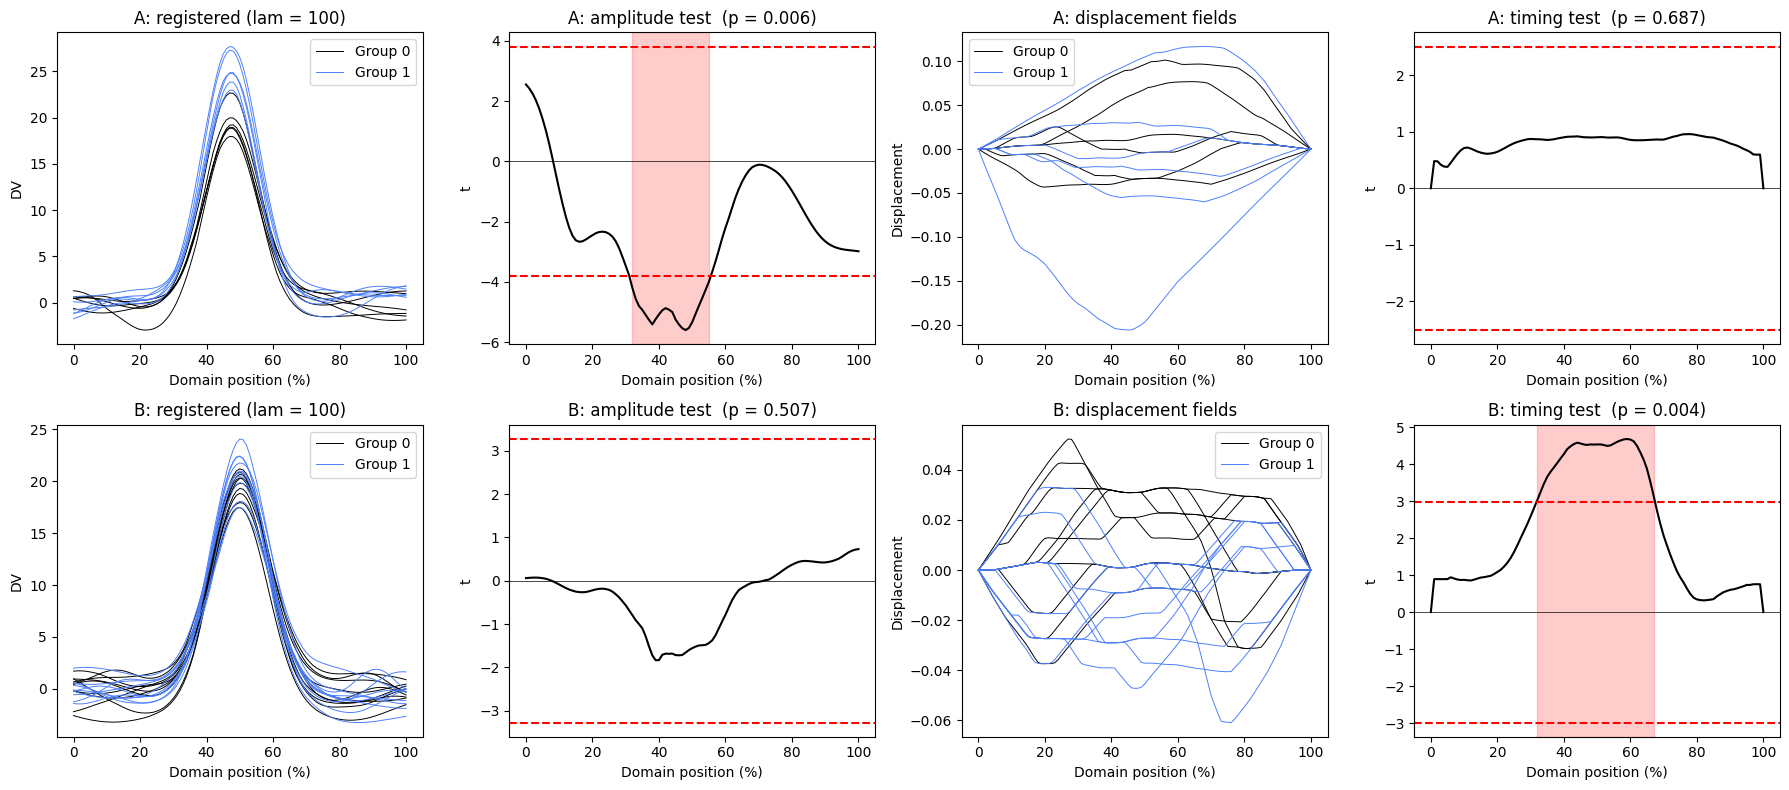

lam =  auto (used 48.6), dataset A: amplitude p = 0.006 [(33, 59)],  timing p = 0.572 []


lam =  auto (used 44.7), dataset B: amplitude p = 0.377 [],  timing p = 0.003 [(35, 65)]


In [4]:
point = analyse(lam=100)
_     = analyse(lam='auto', show=False)

With `lam = 100` both datasets behave exactly as intended: A has an amplitude effect and no
timing effect, B a timing effect and no amplitude effect. Following this finding the default of
`register_srsf` is now `lam='auto'`, the median total variation ∫|f′| of the observations
(here about 49 for A and 45 for B), which gives the same conclusions; `lam=0` reproduces the
unpenalised `fdasrsf` behaviour. `lam=100` is kept for the remainder of this notebook (both for
the SRSF template and for the initialisation of the Bayesian chains). This sensitivity to `lam`
in flat regions is itself a strong argument for uncertainty-aware registration.

## 2. Bayesian registration

For each observation, `register_bayes` samples the posterior of its warp to the SRSF
Karcher-mean template. The point-estimate (dynamic programming) warp initialises each chain.
The credible band of the displacement field is the new information: it says how well determined
each observation's timing is.

Dataset A: 11 s, mean acceptance rate 0.23


Dataset B: 18 s, mean acceptance rate 0.23


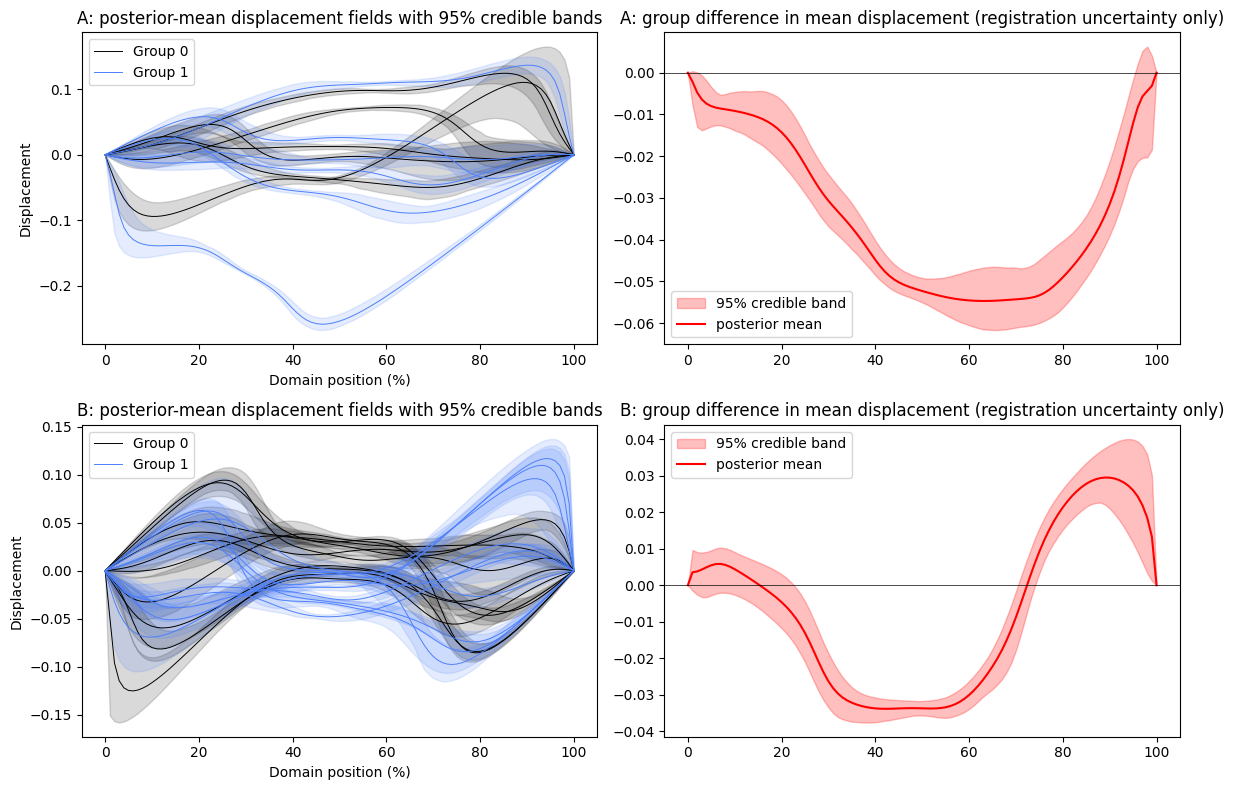

In [5]:
import time
post = {}
for name in 'AB':
    y,g = load(name)
    t0  = time.time()
    rb  = reg1d.register_bayes(y, n_samples=1500, burn=1000, K=8, tau=0.3, random_state=1, max_iter=5, lam=100)
    post[name] = rb
    print(f'Dataset {name}: {time.time()-t0:.0f} s, mean acceptance rate {rb.info["accept"].mean():.2f}')

fig,AX = plt.subplots(2, 2, figsize=(12,8))
x = np.linspace(0, 100, 101)
for row,name in enumerate('AB'):
    rb = post[name]; y,g = load(name)
    for i in range(rb.J):
        ci = rb.info['disp_ci'][i]
        AX[row,0].fill_between(x, ci[0], ci[1], color=colors[g[i]], alpha=0.15)
    plot_groups(rb.displacement_fields, g, AX[row,0], f'{name}: posterior-mean displacement fields with 95% credible bands', 'Displacement')
    # posterior of the group difference in mean displacement (registration uncertainty only)
    S    = rb.info['samples']                                      # (J,S,Q) warp samples
    D    = np.array([reg1d.warp.displacement_field(s) for s in S]) # (J,S,Q) displacement samples
    diff = D[g==1].mean(axis=0) - D[g==0].mean(axis=0)             # (S,Q)
    lo,hi = np.percentile(diff, [2.5, 97.5], axis=0)
    AX[row,1].fill_between(x, lo, hi, color='r', alpha=0.25, label='95% credible band')
    AX[row,1].plot(x, diff.mean(axis=0), 'r', label='posterior mean')
    AX[row,1].axhline(0, color='k', lw=0.5); AX[row,1].legend()
    AX[row,1].set_title(f'{name}: group difference in mean displacement (registration uncertainty only)')
plt.tight_layout(); plt.show()

Note that the credible band of the *group difference* (right column) excludes zero over most of
the domain for dataset A even though A has no timing effect. This is not a contradiction: that
band quantifies only how precisely each individual warp is determined by its own observation;
it says nothing about whether the two groups of warps differ relative to the between-subject
variability, which is what the frequentist timing test measures. A Bayesian answer to the
group question requires either a hierarchical model or the propagation described next.

## 3. Propagating registration uncertainty into the timing test

The credible band of the group difference above reflects only the uncertainty of the
registration (how well each warp is determined given its observation), not the between-subject
variability that the frequentist test is built on. The two sources can be combined in a
simple *posterior-predictive* way: for each posterior draw s, take the s-th warp sample of every
observation, compute the displacement fields, and run the nlreg1d timing test; the distribution
of the resulting test statistics and p-values across draws shows whether the conclusion of the
point-estimate analysis is robust to registration uncertainty.

Dataset A: point-estimate p = 0.687;  over posterior draws: median p = 0.630, fraction of draws with p < 0.05 = 0.00, max|t| range = [1.03, 1.53]


Dataset B: point-estimate p = 0.004;  over posterior draws: median p = 0.000, fraction of draws with p < 0.05 = 1.00, max|t| range = [4.37, 5.67]


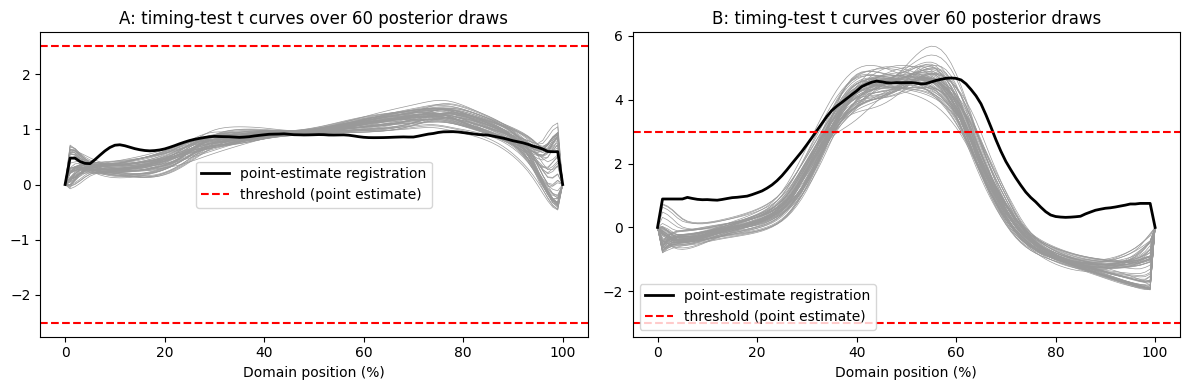

In [6]:
n_draw = 60
fig,AX = plt.subplots(1, 2, figsize=(12,4))
for ax,name in zip(AX, 'AB'):
    rb = post[name]; y,g = load(name)
    S  = rb.info['samples']; idx = np.linspace(0, S.shape[1]-1, n_draw).astype(int)
    pvals, tmaxs = [], []
    for s in idx:
        d  = reg1d.warp.displacement_field(S[:, s, :])
        tt = util.permutation_ttest2(d[g==0], d[g==1], n_perm=300, random_state=int(s))
        pvals.append(tt['p']); tmaxs.append(np.abs(tt['t']).max())
        ax.plot(x, tt['t'], color='0.6', lw=0.5)
    ax.plot(x, point[name]['tim']['t'], 'k', lw=2, label='point-estimate registration')
    ax.axhline(point[name]['tim']['threshold'], color='r', ls='--', label='threshold (point estimate)')
    ax.axhline(-point[name]['tim']['threshold'], color='r', ls='--')
    ax.set_title(f'{name}: timing-test t curves over {n_draw} posterior draws'); ax.legend(); ax.set_xlabel('Domain position (%)')
    pvals = np.array(pvals)
    print(f'Dataset {name}: point-estimate p = {point[name]["tim"]["p"]:.3f};  over posterior draws: median p = {np.median(pvals):.3f}, '
          f'fraction of draws with p < 0.05 = {(pvals < 0.05).mean():.2f}, max|t| range = [{min(tmaxs):.2f}, {max(tmaxs):.2f}]')
plt.tight_layout(); plt.show()

## 4. How the two approaches relate

- **Same estimand, different treatment of uncertainty.** Both approaches quantify timing as a
  displacement field derived from SRSF warps. nlreg1d uses one warp per observation and puts all
  uncertainty into the between-subject variability of the displacement fields; Bayesian
  registration adds a second layer — the uncertainty of each warp given its observation — which
  is invisible to the point-estimate analysis.
- **When it matters.** Around sharp features the posterior of each warp is narrow, the
  posterior-mean warps are close to the dynamic-programming warps, and the timing test's
  conclusion is stable across posterior draws. Registration uncertainty becomes important for
  noisy data, in flat regions of the observations (where the warp is poorly identified — the
  credible bands widen there, and, as section 1 showed, point-estimate methods can produce
  spurious group differences there unless penalised), and near the domain boundaries.
- **What Bayesian registration offers that nlreg1d cannot.** (i) Per-observation credible
  bands for timing (useful for flagging observations whose registration is unreliable, e.g. in a
  front end); (ii) a principled way to propagate registration uncertainty into downstream tests
  (posterior-predictive checks as above, or a fully hierarchical model with group-level warp
  distributions, which would replace the permutation test altogether); (iii) posterior
  probabilities such as P(displacement difference > 0 at t).
- **Costs and caveats.** MCMC is roughly two orders of magnitude slower than dynamic programming;
  results depend on the prior scale (`tau`), the basis size (`K`) and the noise model; and the
  credible bands of this simple model are known to be optimistic because SRSF residuals are
  autocorrelated (the `n_eff` argument tempers the likelihood to compensate). The template is
  fixed at the SRSF Karcher mean; a full treatment would also put a prior on the template.
- **Suggested direction.** A hierarchical Bayesian model (observation warps ~ group-level warp
  distributions on the sphere of √γ′, with a prior on the group difference) would give a direct
  Bayesian counterpart to the nlreg1d timing test, including the amplitude test on the aligned
  functions. The pieces needed (tangent-space parameterisation, pCN sampling) are in `reg1d.bayes`.